In [37]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
def parse_params(params_str):
    params = {}
    for item in params_str.split():
        if '=' in item:
            key, value = item.split('=', 1)
            params[key] = value
    return params

# aggregates results over all parameters except those in params_to_compare
def results_csv_to_df(csv_file, params_to_aggregate=None):
    results = []

    with open(csv_file, newline='') as f:
        reader = csv.DictReader(f, fieldnames=[
            'accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed', 'not_fully_unmasked',
            'checkpoint', 'strategy', 'params'
        ])
        reader.__next__()  # Skip header row
        for row in reader:
            params = parse_params(row['params'])
            row_dict = {
                'accuracy': float(row['accuracy']),
                'correctly_filled_cells': float(row['correctly_filled_cells']),
                'checkpoint': row['checkpoint'],
                'strategy': row['strategy'],
                'nfe': float(row['nfe']),
                'time': float(row['time']),
                'speed': float(row['speed']),
            }
            row_dict.update(params.items())
            results.append(row_dict)
    
    results_df = pd.DataFrame(results)
    print(f"Total rows before aggregation: {len(results_df)}")
    
    # Aggregate the accuracy, correctly_filled_cells, nfe, time, and speed over the rows where all parameters except those in params_to_aggregate are the same
    if params_to_aggregate is not None:
        groupby_cols = [col for col in results_df.columns if col not in params_to_aggregate + ['accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed']]
    else:
        groupby_cols = [col for col in results_df.columns if col not in ['accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed']]
    
    aggregated_df = results_df.groupby(groupby_cols, dropna=False).agg(
        accuracy_mean=pd.NamedAgg(column='accuracy', aggfunc='mean'),
        accuracy_std=pd.NamedAgg(column='accuracy', aggfunc='std'),
        correctly_filled_cells_mean=pd.NamedAgg(column='correctly_filled_cells', aggfunc='mean'),
        correctly_filled_cells_std=pd.NamedAgg(column='correctly_filled_cells', aggfunc='std'),
        nfe=pd.NamedAgg(column='nfe', aggfunc='mean'),
        time=pd.NamedAgg(column='time', aggfunc='mean'),
        speed=pd.NamedAgg(column='speed', aggfunc='mean'),
    ).reset_index()

    print(f"Rows after aggregation: {len(aggregated_df)}")
    return aggregated_df

In [39]:
params_to_aggregate = ['seed']
df = results_csv_to_df('results_acc_nfe.csv', params_to_aggregate=params_to_aggregate)
df

Total rows before aggregation: 36
Rows after aggregation: 36


,checkpoint,strategy,score_position_for_change,select_position,change_token,k,gumbel_noise_coefficient,self_correction,dataset,num_samples,...,position_sampling,position_metric,token_sampling,accuracy_mean,accuracy_std,correctly_filled_cells_mean,correctly_filled_cells_std,nfe,time,speed
0,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.6872,NaN,0.8572,NaN,95.19,7026.0,0.91
1,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.7044,NaN,0.8641,NaN,114.11,9957.0,0.64
2,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.7373,NaN,0.8780,NaN,242.27,17765.0,0.36
3,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.7670,NaN,0.8896,NaN,335.38,24986.0,0.26
4,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.6777,NaN,0.8537,NaN,1.25,320.0,20.01
5,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,16,0,none,hard,6400,...,NaN,NaN,NaN,0.0023,NaN,0.7172,NaN,0.10,22.0,290.63
6,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,2,0,none,hard,6400,...,NaN,NaN,NaN,0.3167,NaN,0.8386,NaN,1.14,362.0,17.70
7,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,4,0,none,hard,6400,...,NaN,NaN,NaN,0.1686,NaN,0.8139,NaN,0.47,138.0,46.26
8,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,8,0,none,hard,6400,...,NaN,NaN,NaN,0.1214,NaN,0.7634,NaN,0.25,93.0,68.91
9,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,NaN,NaN,change_max,1,0,NaN,hard,6400,...,NaN,NaN,NaN,0.6905,NaN,0.8582,NaN,103.28,7973.0,0.80


In [40]:
strategy_to_label = {
    'mdlm_adaptive_score_select_update': 'MD top-k probability',
    'gidd_change_based_on_model_confidence_to_change': 'Mask current token',
    'gidd_change_low_confidence_positions': 'Fix low-confidence tokens',
}

In [41]:
def plot_subset(x_axis, subset, label, strategy_color, marker, linestyle):
    if not subset.empty:
        plt.plot(subset[x_axis], subset['accuracy_mean'], 
                label=label,
                marker=marker,
                color=strategy_color,
                linestyle=linestyle,
                markersize=6, alpha=0.7, linewidth=2)

In [42]:
filtered_data = df
filtered_data = df[df['strategy'] != 'gidd_prob_to_recover_data']
filtered_data['position_sampling'] = 0

/tmp/ipykernel_3319390/443988578.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['position_sampling'] = 0


/tmp/ipykernel_3319390/758242077.py:71: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


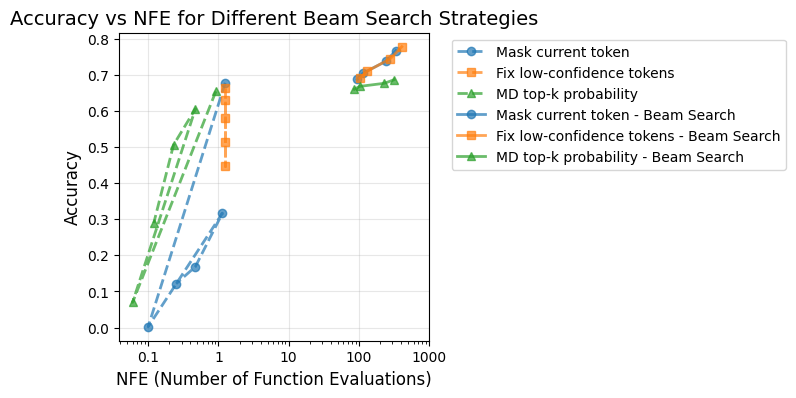

In [43]:
# Plot accuracy vs NFE for each strategy

# Filter data
# filtered_data = df
# filtered_data = df[df['do_beam_search'] == 'true']
# filtered_data = df[df['do_beam_search'] == 'false']
# filtered_data = df[df['strategy'] != 'gidd_prob_to_recover_data']

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
df_by_category = {
    'independent': filtered_data[
        (filtered_data['strategy'].isin(['mdlm_vanilla', 'gidd_independent_positions_decomposed_update_distribution'])) |
        ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'independent'))
    ],
    'top_k': filtered_data[
        (
            (filtered_data['strategy'].isin(['mdlm_adaptive_score_select_update', 'gidd_change_low_confidence_positions', 'gidd_change_based_on_model_confidence_to_change'])) |
            ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'top_k'))
        ) & (filtered_data['do_beam_search'] == 'false')
    ],
    'beam_search': filtered_data[
        (filtered_data['do_beam_search'] == 'true')
    ]
}

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))
strategies_to_index = {strategy: idx for idx, strategy in enumerate(strategies)}

for category, category_data in df_by_category.items():
    if len(category_data) == 0:
        continue
    # print('a')
    current_strategies = category_data['strategy'].unique()
    current_checkpoints = category_data['checkpoint'].unique()
    for strategy in current_strategies:
        # print('b')
        for checkpoint in current_checkpoints:
            strategy_color = colors[strategies_to_index[strategy]]
            subset = category_data[
                (category_data['strategy'] == strategy) & 
                (category_data['checkpoint'] == checkpoint)
            ]
            if len(subset) == 0:
                continue
            # print('c')
            if category == 'beam_search':
                linestyle = '-'
                label = f'{strategy_to_label.get(strategy, strategy)} - Beam Search'
                plot_subset('nfe', subset, label, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)
            if category == 'top_k':
                linestyle = '--'
                label = f'{strategy_to_label.get(strategy, strategy)}'
                plot_subset('nfe', subset, label, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)
            

plt.xlabel('NFE (Number of Function Evaluations)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs NFE for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
plt.xticks([0.1, 1, 10, 100, 1000], [0.1, 1, 10, 100, 1000])
# plt.xticks([80, 100, 200, 300, 400], [80, 100, 200, 300, 400])
plt.tight_layout()
plt.show()


/tmp/ipykernel_3319390/3174009864.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


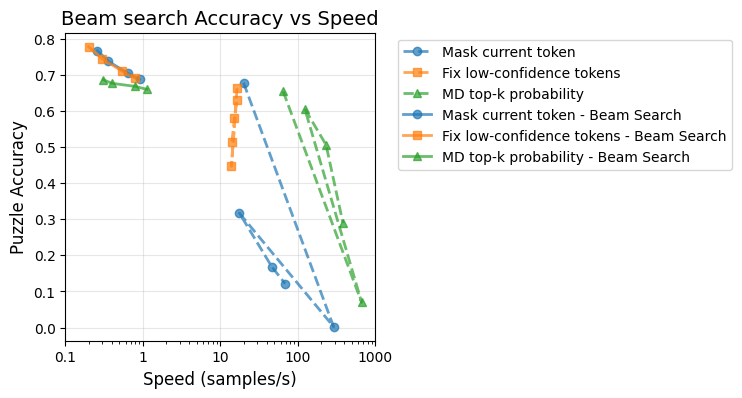

In [44]:
# Plot accuracy vs speed for each strategy with specific filtering

# Filter data
# filtered_data = df
# filtered_data = df[df['do_beam_search'] == 'true']
# filtered_data = df[df['do_beam_search'] == 'false']
# filtered_data = df[df['strategy'] != 'gidd_prob_to_recover_data']

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
df_by_category = {
    'independent': filtered_data[
        (filtered_data['strategy'].isin(['mdlm_vanilla', 'gidd_independent_positions_decomposed_update_distribution'])) |
        ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'independent'))
    ],
    'top_k': filtered_data[
        (
            (filtered_data['strategy'].isin(['mdlm_adaptive_score_select_update', 'gidd_change_low_confidence_positions', 'gidd_change_based_on_model_confidence_to_change'])) |
            ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'top_k'))
        ) & (filtered_data['do_beam_search'] == 'false')
    ],
    'beam_search': filtered_data[
        (filtered_data['do_beam_search'] == 'true')
    ]
}

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))
strategies_to_index = {strategy: idx for idx, strategy in enumerate(strategies)}

for category, category_data in df_by_category.items():
    if len(category_data) == 0:
        continue
    # print('a')
    current_strategies = category_data['strategy'].unique()
    current_checkpoints = category_data['checkpoint'].unique()
    for strategy in current_strategies:
        # print('b')
        for checkpoint in current_checkpoints:
            strategy_color = colors[strategies_to_index[strategy]]
            subset = category_data[
                (category_data['strategy'] == strategy) & 
                (category_data['checkpoint'] == checkpoint)
            ]
            if len(subset) == 0:
                continue
            # print('c')
            if category == 'beam_search':
                linestyle = '-'
                label = f'{strategy_to_label.get(strategy, strategy)} - Beam Search'
                plot_subset('speed', subset, label, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)
            if category == 'top_k':
                linestyle = '--'
                label = f'{strategy_to_label.get(strategy, strategy)}'
                plot_subset('speed', subset, label, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)

plt.xlabel('Speed (samples/s)', fontsize=12)
plt.ylabel('Puzzle Accuracy', fontsize=12)
plt.title('Beam search Accuracy vs Speed', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
plt.xticks([0.1, 1, 10, 100, 1000], [0.1, 1, 10, 100, 1000])
# plt.xticks([0.2, 0.3, 0.4, 0.6, 0.8, 1.2], ['0.2', '0.3', '0.4', '0.6', '0.8', '1.2'])
plt.tight_layout()
plt.show()


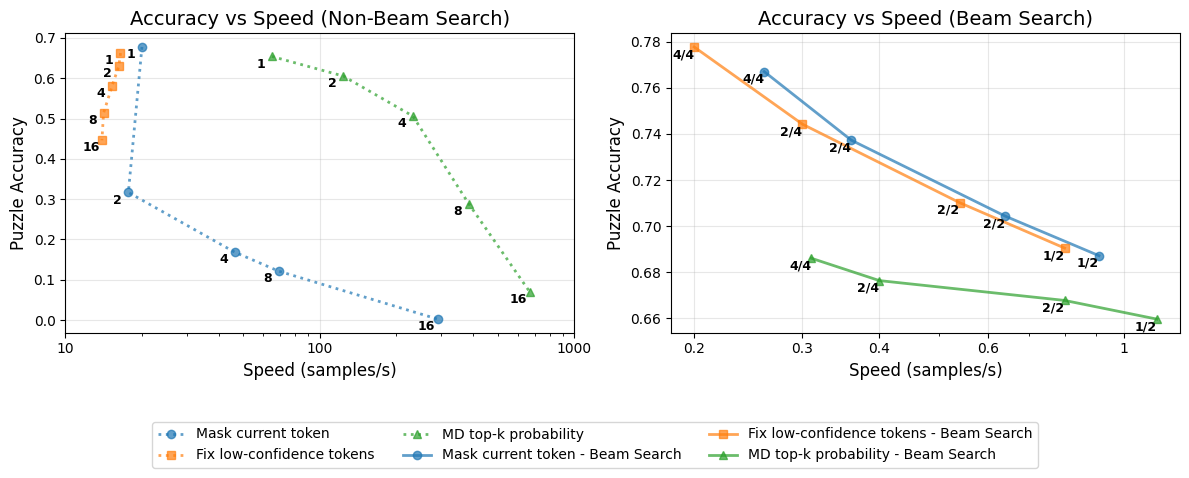

In [52]:
# Plot accuracy vs speed for each strategy with specific filtering - Split into subplots

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
df_by_category = {
    'independent': filtered_data[
        (filtered_data['strategy'].isin(['mdlm_vanilla', 'gidd_independent_positions_decomposed_update_distribution'])) |
        ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'independent'))
    ],
    'top_k': filtered_data[
        (
            (filtered_data['strategy'].isin(['mdlm_adaptive_score_select_update', 'gidd_change_low_confidence_positions', 'gidd_change_based_on_model_confidence_to_change'])) |
            ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'top_k'))
        ) & (filtered_data['do_beam_search'] == 'false')
    ],
    'beam_search': filtered_data[
        (filtered_data['do_beam_search'] == 'true')
    ]
}

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))
strategies_to_index = {strategy: idx for idx, strategy in enumerate(strategies)}

def plot_subset_on_axis(ax, x_axis, subset, label, strategy_color, marker, linestyle, sort_by=None, text_labels=None):
    if not subset.empty:
        # Sort by the specified column or default to x_axis
        if sort_by is not None:
            subset_sorted = subset.sort_values(sort_by)
        else:
            subset_sorted = subset.sort_values(x_axis)
        line = ax.plot(subset_sorted[x_axis], subset_sorted['accuracy_mean'], 
                label=label,
                marker=marker,
                color=strategy_color,
                linestyle=linestyle,
                markersize=6, alpha=0.7, linewidth=2)
        
        # Add text labels to points
        if text_labels is not None:
            for i, (idx, row) in enumerate(subset_sorted.iterrows()):
                ax.annotate(text_labels[i], 
                           (row[x_axis], row['accuracy_mean']),
                           textcoords="offset points",
                           xytext=(-8,-8),
                           ha='center',
                           fontsize=9,
                           color='black',
                        #    bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.8, edgecolor='none'),
                           fontweight='bold')
        
        return line[0]
    return None

# Collect all line objects for combined legend and track y-axis range
all_lines = []
all_labels = []
all_y_values = []

# Plot non-beam search strategies (top_k)
for category, category_data in df_by_category.items():
    if len(category_data) == 0:
        continue
    current_strategies = category_data['strategy'].unique()
    current_checkpoints = category_data['checkpoint'].unique()
    
    for strategy in current_strategies:
        for checkpoint in current_checkpoints:
            strategy_color = colors[strategies_to_index[strategy]]
            subset = category_data[
                (category_data['strategy'] == strategy) & 
                (category_data['checkpoint'] == checkpoint)
            ]
            if len(subset) == 0:
                continue
                
            # Collect y values for range calculation
            all_y_values.extend(subset['accuracy_mean'].tolist())
                
            if category == 'top_k':
                linestyle = ':'
                label = f'{strategy_to_label.get(strategy, strategy)}'
                # Convert k to numeric for proper sorting
                subset_copy = subset.copy()
                subset_copy['k_numeric'] = pd.to_numeric(subset_copy['k'], errors='coerce')
                subset_sorted = subset_copy.sort_values('k_numeric')
                # Create text labels with k values
                text_labels = [str(int(k)) for k in subset_sorted['k_numeric']]
                line = plot_subset_on_axis(ax1, 'speed', subset_copy, label, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle, sort_by='k_numeric', text_labels=text_labels)
                if line and label not in all_labels:
                    all_lines.append(line)
                    all_labels.append(label)
            elif category == 'beam_search':
                linestyle = '-'
                label = f'{strategy_to_label.get(strategy, strategy)} - Beam Search'
                # Convert beam search parameters to numeric for proper sorting
                subset_copy = subset.copy()
                subset_copy['pruning_num_beams_numeric'] = pd.to_numeric(subset_copy['pruning_num_beams'], errors='coerce')
                subset_copy['branching_factor_numeric'] = pd.to_numeric(subset_copy['branching_factor'], errors='coerce')
                subset_sorted = subset_copy.sort_values(['pruning_num_beams_numeric', 'branching_factor_numeric'])
                # Create text labels with pruning_num_beams/branching_factor format
                text_labels = []
                for _, row in subset_sorted.iterrows():
                    pruning_beams = str(int(row['pruning_num_beams_numeric']))
                    branching_factor = str(int(row['branching_factor_numeric']))
                    text_labels.append(f"{pruning_beams}/{branching_factor}")
                line = plot_subset_on_axis(ax2, 'speed', subset_copy, label, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle, sort_by=['pruning_num_beams_numeric', 'branching_factor_numeric'], text_labels=text_labels)
                if line and label not in all_labels:
                    all_lines.append(line)
                    all_labels.append(label)

# Calculate common y-axis range
y_min = min(all_y_values) * 0.95  # Add small margin
y_max = max(all_y_values) * 1.05  # Add small margin

# Configure first subplot (non-beam search)
ax1.set_xlabel('Speed (samples/s)', fontsize=12)
ax1.set_ylabel('Puzzle Accuracy', fontsize=12)
ax1.set_title('Accuracy vs Speed (Non-Beam Search)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
# ax1.set_xticks([0.1, 1, 10, 100, 1000])
# ax1.set_xticklabels([0.1, 1, 10, 100, 1000])
ax1.set_xticks([10, 100, 1000])
ax1.set_xticklabels([10, 100, 1000])
# ax1.set_ylim(y_min, y_max)

# Configure second subplot (beam search)
ax2.set_xlabel('Speed (samples/s)', fontsize=12)
ax2.set_ylabel('Puzzle Accuracy', fontsize=12)
ax2.set_title('Accuracy vs Speed (Beam Search)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
# ax2.set_xticks([0.1, 1, 10, 100, 1000])
# ax2.set_xticklabels([0.1, 1, 10, 100, 1000])
ax2.set_xticks([0.2, 0.3, 0.4, 0.6, 1])
ax2.set_xticklabels([0.2, 0.3, 0.4, 0.6, 1])
# ax2.set_ylim(y_min, y_max)

# Add combined legend below the plots
fig.legend(all_lines, all_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

plt.tight_layout()
plt.show()